In [1]:
import os
os.chdir("../")
configs_file = "train_debug"

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
jax.config.update("jax_default_matmul_precision", "float32") 
import jax.numpy as jnp
import matplotlib.pyplot as plt


from ice_melting.configs import load_configs
configs = load_configs(configs_file)


from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
import seaborn as sns
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})

In [3]:
data_dir = "data/ice_melting/circle"
init_params = jnp.load(f"{data_dir}/initial_params.npy")
times = jnp.load(f"{data_dir}/times.npy")
init_params.shape

(1, 3)

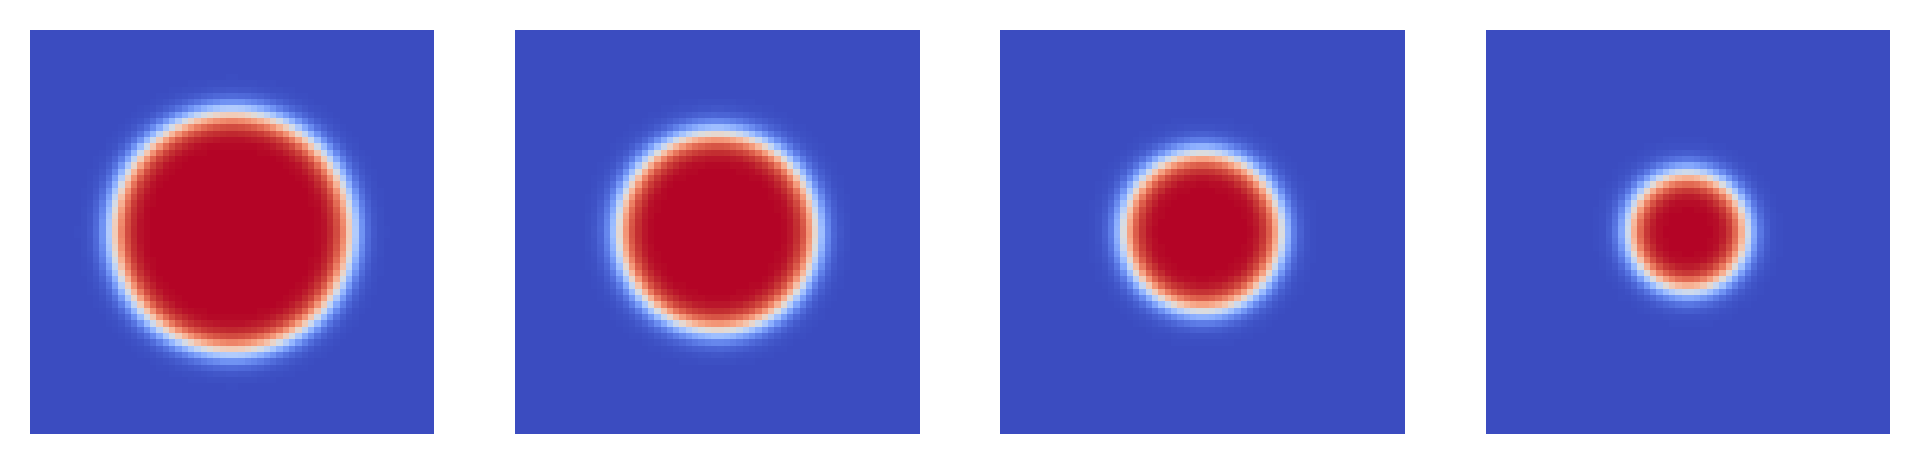

In [4]:
mesh = jnp.load(f"{data_dir}/mesh_points.npy") # shape: (2, H, W)
meshx = mesh[0]
meshy = mesh[1]
solutions = jnp.load(f"{data_dir}/solutions.npy") # shape: (num_examples, num_time_steps,C=1,  H, W)

tics = [0, 10, 20, 30]
examples = [0]
fig, axs = plt.subplots(1, len(tics), figsize=(8, 3))
for i, tic in enumerate(tics):
    sol = solutions[0, tic, 0] # shape: (H, W)
    ax = axs[i]
    cont = ax.pcolormesh(meshx, meshy, sol, cmap="coolwarm", shading="auto", rasterized=True)
    ax.set_aspect('equal')
    ax.set_axis_off()

In [5]:
u0 = solutions[:, 0, ...] # B=1, C=1, H=64, W=64


In [6]:
ts = jnp.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]) # shape: (T,)
# fined the closed index in `times`
meshx = mesh[0] # shape: (H, W)
meshy = mesh[1] # shape: (H, W)

# formulate (H*W, 2) array for spatial coordinates
H, W = meshx.shape
x_coord = jnp.stack([meshx.reshape(-1), meshy.reshape(-1)], axis=-1) / configs.Lc
# shape: (H*W, 2)


In [7]:
def ic_fn(a, b, theta, x, y, epsilon, Lc=None):
    # a, b, x, y, are expected to be the physical coordinates
    
    if Lc is not None:
        # indicate that x, y are normalized coordinates
        x = x * Lc
        y = y * Lc

    # a, b, theta: scalars
    x_rot = x * jnp.cos(theta) + y * jnp.sin(theta)
    y_rot = -x * jnp.sin(theta) + y * jnp.cos(theta)

    term = jnp.sqrt((x_rot / a)**2 + (y_rot / b)**2) 
    scale = 2 * a * b / (a + b)
    dist = scale * (1.0 - term)

    u = jnp.tanh(dist / (jnp.sqrt(2) * epsilon)) # shape (H, W) or scalar
    return u

In [8]:
from models import get_model

key = jax.random.PRNGKey(0)
model_params = configs.model_params
if configs.use_hard_constraint:
    model_params.update(dict(
        hard_cons_fn=partial(ic_fn, epsilon=configs.epsilon, Lc=configs.Lc),
    ))
model_skeleton = get_model(
    model_name=configs.model_name,
    key=key,
    **model_params,
)

weight = "/root/autodl-tmp/tf-logs/ice_melting/circle/20251228-000736/model_epoch_25000.eqx"
model = eqx.tree_deserialise_leaves(weight, model_skeleton)

In [9]:
from models.sample import lhs_sampling
xs = jnp.linspace(*configs.spatial_domain[0], 64)
ys = jnp.linspace(*configs.spatial_domain[1], 64)
xx, yy = jnp.meshgrid(xs, ys, indexing="xy")
x_coord = jnp.stack([xx.reshape(-1), yy.reshape(-1)], axis=-1)
print(x_coord.shape)

u0 = ic_fn(30, 30, 0.0, x_coord[:, 0]*configs.Lc, x_coord[:, 1]*configs.Lc, configs.epsilon)
u0 = u0.reshape(1, 64, 64)

# fig, ax = plt.subplots(1, 1, figsize=(3, 3))
# cont = ax.pcolormesh(xx*configs.Lc, yy*configs.Lc, u0[0], cmap="coolwarm", shading="auto", rasterized=True)
# ax.set_aspect('equal')
# plt.colorbar(cont, ax=ax)

(4096, 2)


In [10]:
param = jnp.array([30, 30, 0.0])

def body_fn(carry, t):
    t_coord = jnp.full((x_coord.shape[0], 1), t) / configs.Tc
    sol = model(u0, param, x_coord, t_coord) # shape: (H*W, 1)
    return carry, sol

_, sols = jax.lax.scan(body_fn, None, ts)
# sols shape from scan: (T, H*W, 1)
sols = sols.transpose(1, 2, 0).reshape(64, 64, -1) # shape: (H, W, T)
print(sols.min(), sols.max())

-1.0004232 1.0001298


In [11]:
idxs = jnp.array([jnp.argmin(jnp.abs(times - t)) for t in ts]) # shape: (T,)
ref_sols = solutions[0, idxs, 0, :, :]
# reshape as H, W, T
ref_sols = ref_sols.transpose(1, 2, 0)
ref_sols.shape

(64, 64, 7)

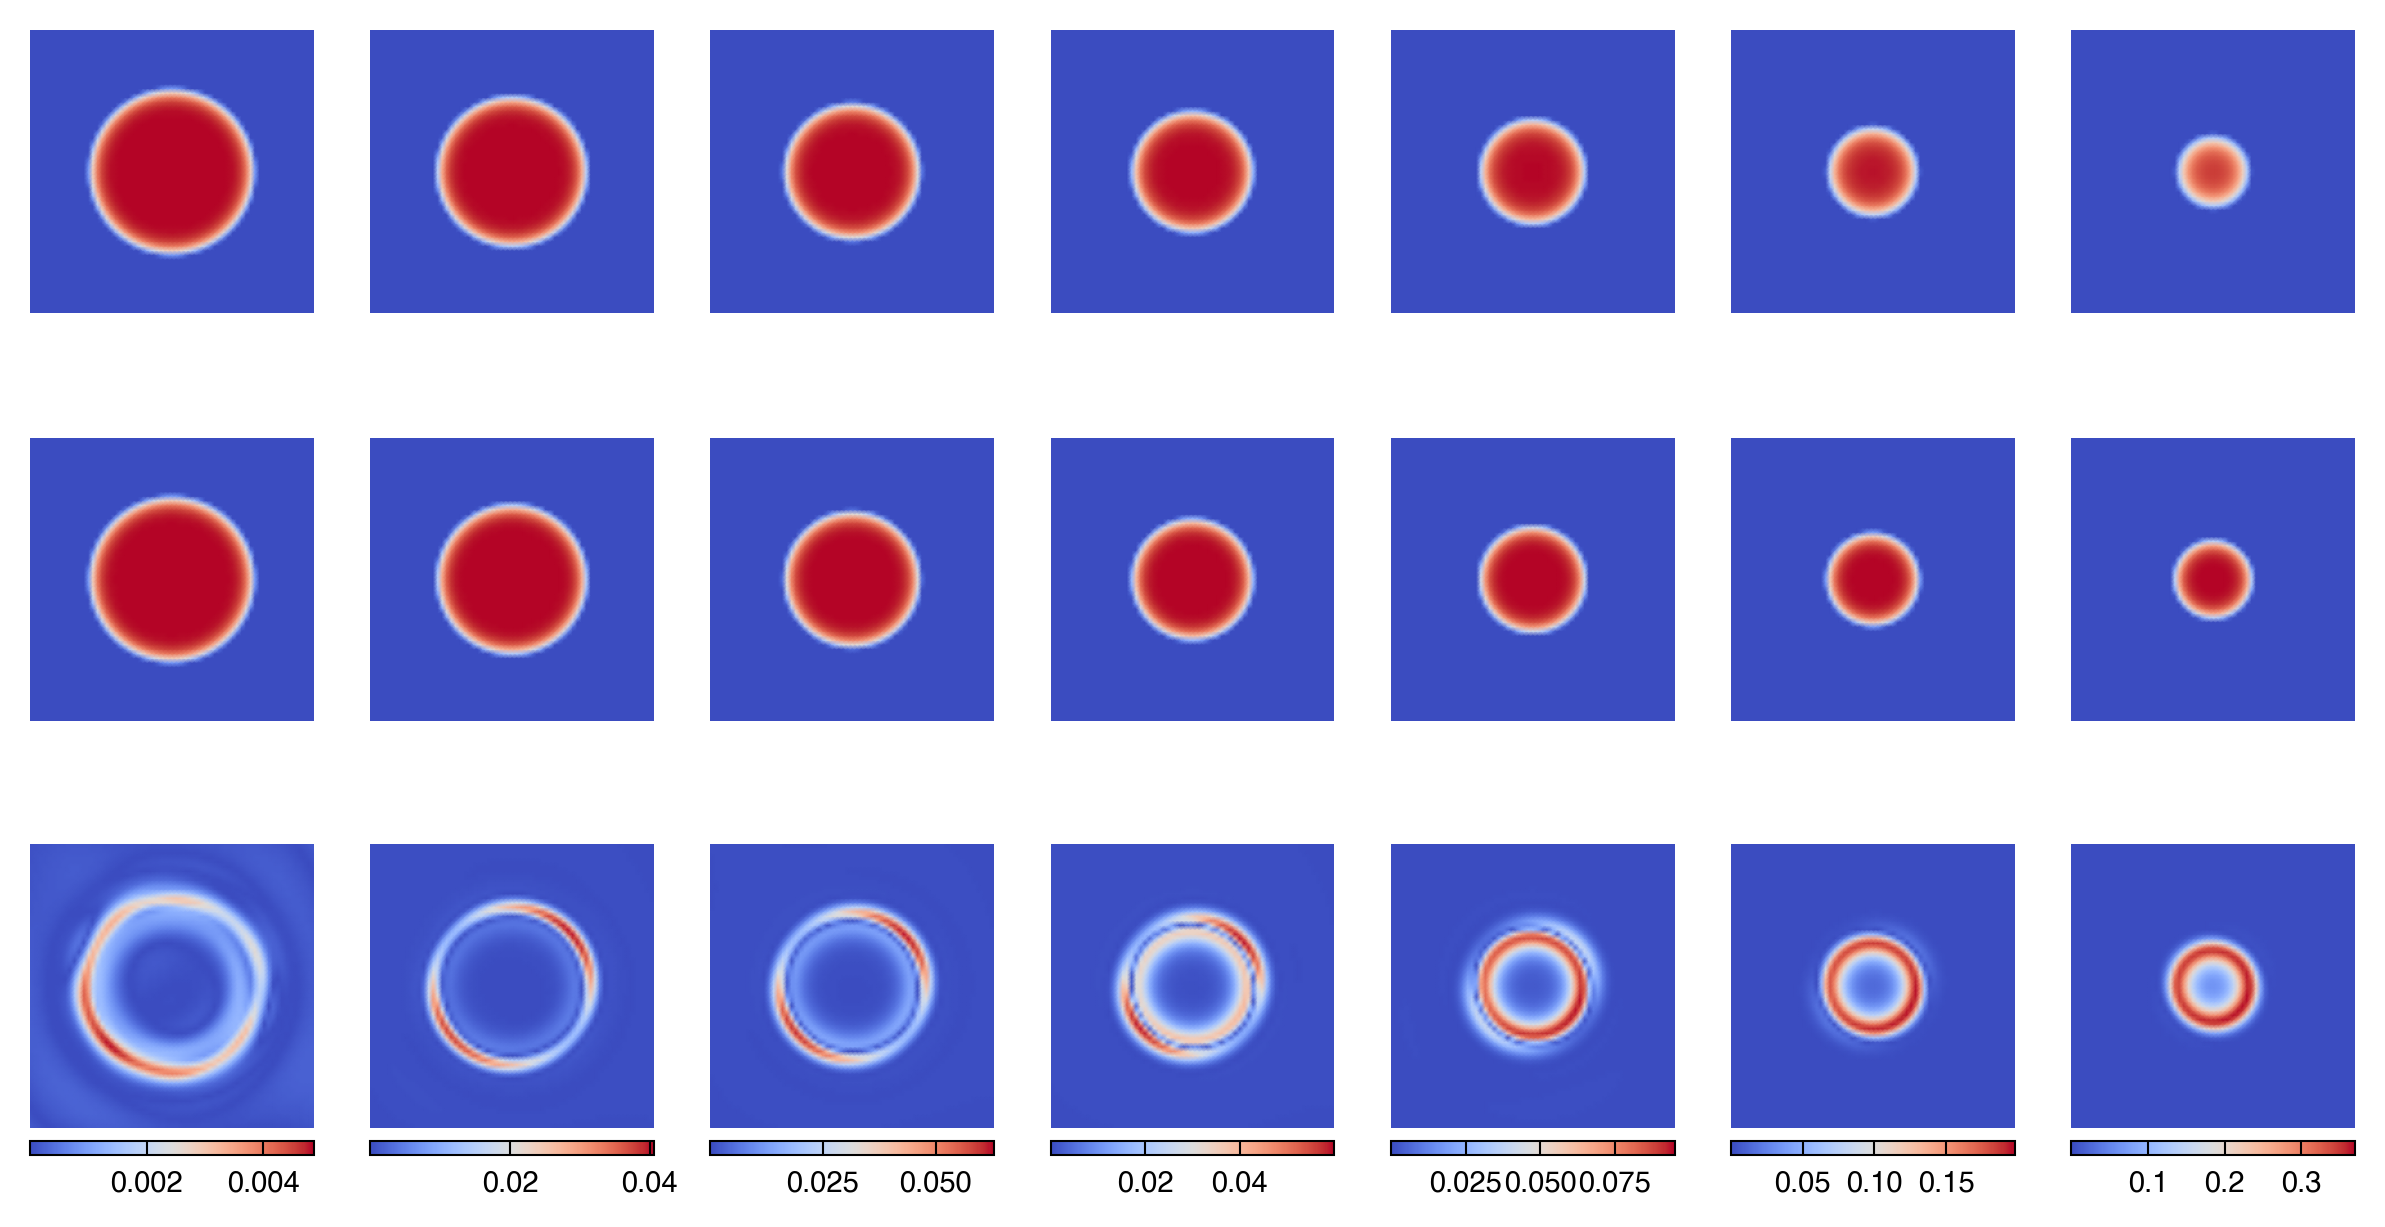

In [12]:
fig, axes = plt.subplots(3, len(ts), figsize=(10, 5))
for i, tic in enumerate(ts):
    ax = axes[0, i]
    ax.pcolormesh(meshx, meshy, sols[:, :, i], cmap="coolwarm", 
                  shading='gouraud', rasterized=True,
                  vmin=0, vmax=1)
    ax.set_aspect("equal")
    ax.set_axis_off()

    ax = axes[1, i]
    ax.pcolormesh(meshx, meshy, ref_sols[:, :, i], cmap="coolwarm", 
                  shading='gouraud', rasterized=True,
                  vmin=0, vmax=1)
    ax.set_aspect("equal")
    ax.set_axis_off()

    ax = axes[2, i]
    diff = jnp.abs(sols[:, :, i] - ref_sols[:, :, i])
    diff_cont = ax.pcolormesh(meshx, meshy, diff, cmap="coolwarm", 
                             shading='gouraud', rasterized=True,)
    ax.set_aspect("equal")
    ax.set_axis_off()

    colorbar = fig.colorbar(diff_cont, ax=ax, fraction=0.046, pad=0.04, orientation='horizontal')